In [22]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(min(len(w) for w in words))
print(max(len(w) for w in words))

32033
2
15


In [23]:
# Bigram LM just works 2 characters at a time: prediciting the latter giving the former


b = {}
for w in words:
    chs = ['>S<'] + list(w) + ['>E<'] # to get start and end of each word
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 


In [24]:
sorted(b.items(), key = lambda key_value: -key_value[1]) # bigrams sorted by key value (count) backwards


[(('n', '>E<'), 6763),
 (('a', '>E<'), 6640),
 (('a', 'n'), 5438),
 (('>S<', 'a'), 4410),
 (('e', '>E<'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('>S<', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('>S<', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '>E<'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('>S<', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '>E<'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('>S<', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '>E<'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('>S<', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('>S<', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('>S<', 'l'), 1572),
 (('>S<', 'c'), 1542),
 (('>S<', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [ ]:
# 2d array better suited to store the bigrams
import torch 

N = torch.zeros((27,27), dtype=torch.int32) 

chars = sorted(list(set(''.join(words))))
str_to_index = {string : index+1 for index,string in enumerate(chars)}
str_to_index['.'] = 0


# move the bigram counts into a tensor (array)

for w in words :

    chs = ['.'] + list(w) + ['.']  # ['>S<]' and ['>E<]' have been replaced by '.' as it is more clean
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = str_to_index[ch1]
        ix2 = str_to_index[ch2]
        N[ix1, ix2] += 1

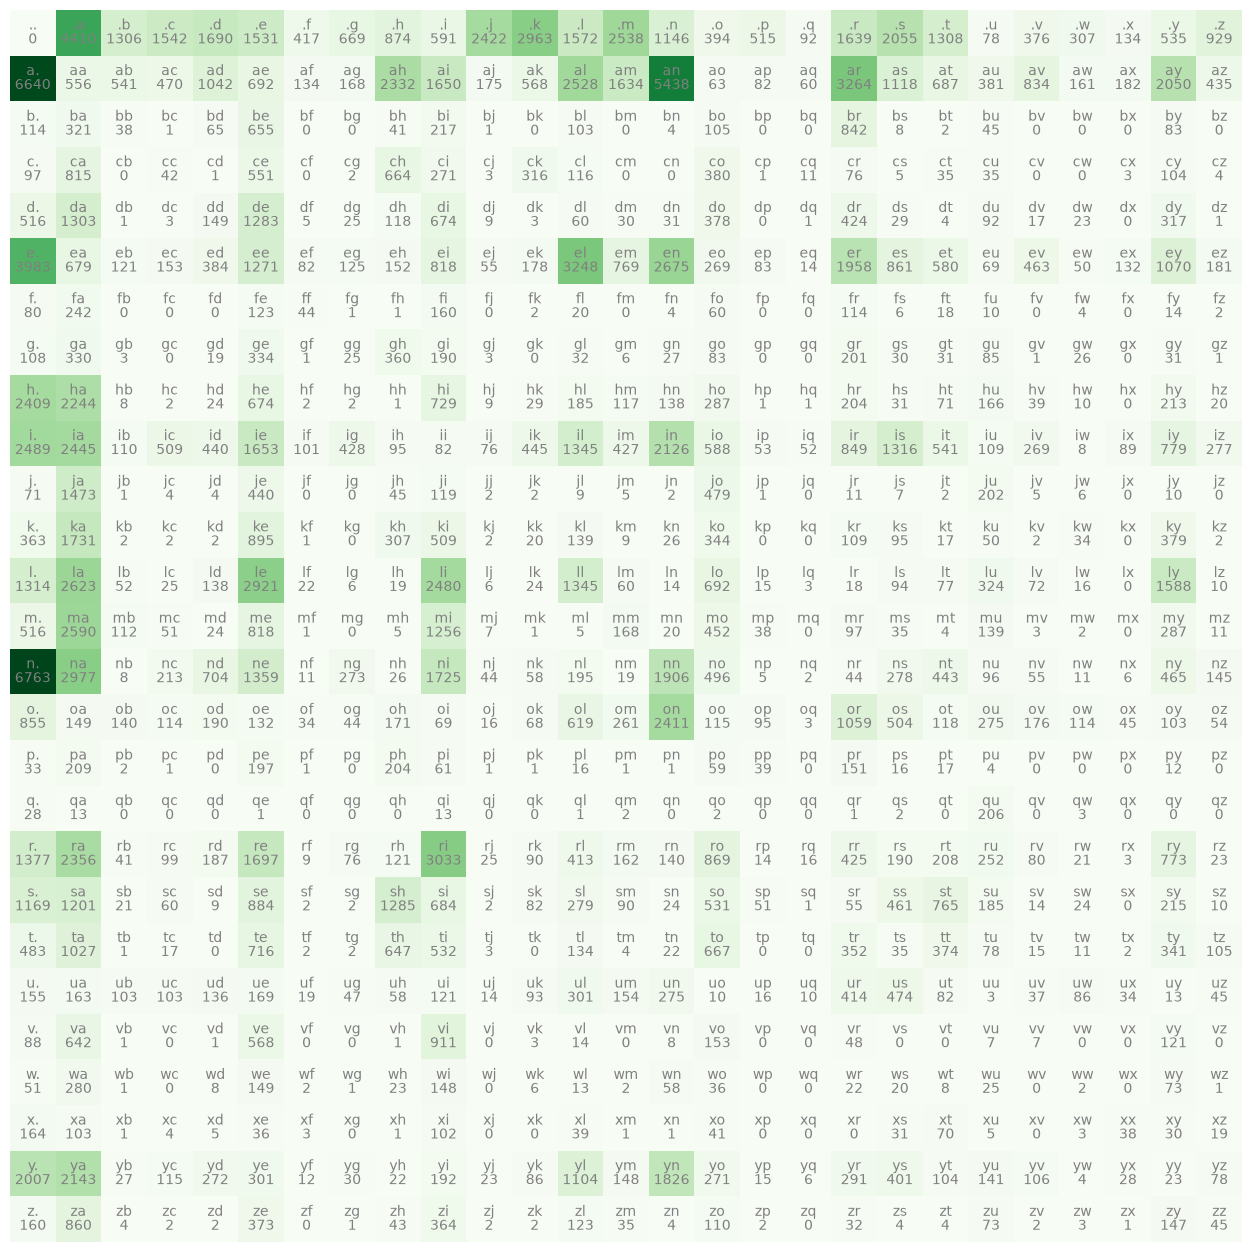

In [26]:
import matplotlib.pyplot as plt

index_to_string = {index:string for string, index in str_to_index.items()}

plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Greens')
for i in range(27):
    for j in range(27):
        chstr = index_to_string[i] + index_to_string[j]
        plt.text( j, i , chstr, ha='center', va='bottom', color='gray')
        plt.text(j, i, N[i, j].item(), ha='center', va='top', color='gray')
plt.axis('off')
plt.show()

In [27]:
p = N[0].float()
p = p / p.sum() # to normalise the values
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [28]:
g = torch.Generator().manual_seed(16)
ix = torch.multinomial( p, num_samples = 1, replacement= True, generator = g).item()
index_to_string[ix]

'z'

In [29]:
g = torch.Generator().manual_seed(16)
p = torch.rand(3, generator=g)
p = p / p.sum()
p

tensor([0.0947, 0.3636, 0.5418])

In [30]:
torch.multinomial(p, num_samples=100, replacement=True, generator= g)

tensor([0, 0, 0, 2, 1, 0, 1, 2, 2, 1, 1, 2, 2, 0, 1, 1, 2, 0, 0, 0, 2, 1, 1, 2,
        0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 0, 2, 2, 2, 2, 1, 1, 2, 2, 1, 2,
        0, 1, 2, 2, 2, 0, 1, 1, 2, 2, 1, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 2, 2,
        2, 2, 2, 1, 1, 2, 1, 1, 1, 2, 0, 2, 1, 2, 1, 2, 2, 2, 2, 0, 2, 2, 2, 2,
        2, 2, 1, 1])

In [34]:
P = N.float()
P /= P.sum(1, keepdims=True)

In [35]:
g = torch.Generator().manual_seed(16)
 
for i in range(5):
        
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(index_to_string[ix])
        if ix == 0:
            break
    print(' '.join(out))  # quite poor names

z a .
k a h a r i .
z y d a h a h r a r o v y n i s o s t o r i n g e e r u .
e .
g t e v a l e i a e c a .


In [45]:
# To evaluate the quality of bigram model, I use the training loss. 

log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.'] # to get start and end of each word
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = str_to_index[ch1]
        ix2 = str_to_index[ch2]
        prob = P[ix1, ix2]
        logprob =torch.log(prob)
        log_likelihood += logprob
        n += 1
        # print(f'{ch1}{ch2}: {prob: .4f}  {logprob: .4f}')

neg_log_lk = -log_likelihood
print(f'Negative log likelihoood (loss): {neg_log_lk}')
print(f'Normalized loss: {neg_log_lk/n}')  # the lower the more accurate the model is 
# 1/ 27.0 = 0.037037037037037035 probability of starting char in they were all the same


Negative log likelihoood (loss): 559891.75
Normalized loss: 2.454094171524048


 1/ 27.0 = 0.037037037037037035 probability of starting char in they were all the same.
 To measure the quality of the bigram model, MLE is used (log MLE).
 The goal is to find those parameters which increase the likelihood and its log transform, and therefore reduce the negative one (loss), yielding better results.

